In [1]:
!pip install PyPDF2
!pip install spacy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 12.2 MB/s eta 0:00:00


In [2]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# Data read/write
import PyPDF2
import numpy as np
import pandas as pd

# Data Visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

In [4]:
# Function to convert from list to str
def listToString(s):

    # initialize an empty string
    str1 = " "

    # return string
    return (str1.join(s))

In [5]:
def get_freq_word(TEXT_list):
    """This method get count the frequency of each word in the passed parameter"""
    Vocab_list = ' '.join(TEXT_list)
    temp_dict = Counter(Vocab_list.split()).items()
    freq_df = pd.DataFrame(temp_dict)
    freq_df = freq_df.sort_values(1, ascending = False)
    return freq_df

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Chapter name:**
* Ear & Nose.
* Musculoskeletal
* Respiratory

In [12]:
# specify file path
path = "/content/drive/MyDrive/all_chapters.pdf"

# open file and read it through PyPDF2 packages
ff = open( path ,"rb")
reader = PyPDF2.PdfReader(ff)

# print the total pages number
print(len(reader.pages))
total_page = len(reader.pages)

313


In [13]:
list_from_pdf =[]
article = " "

# loop through the pages and assign/save the page content in list and str
for page_num in range(0,313):
    pageObj = reader.pages[page_num]
    extract = pageObj.extract_text().split("\n")
    article += listToString(extract)
    list_from_pdf.append(extract)

In [14]:
# save the book content in dataframe
df = pd.DataFrame([article], columns=['string_values'])

### Data Visualize

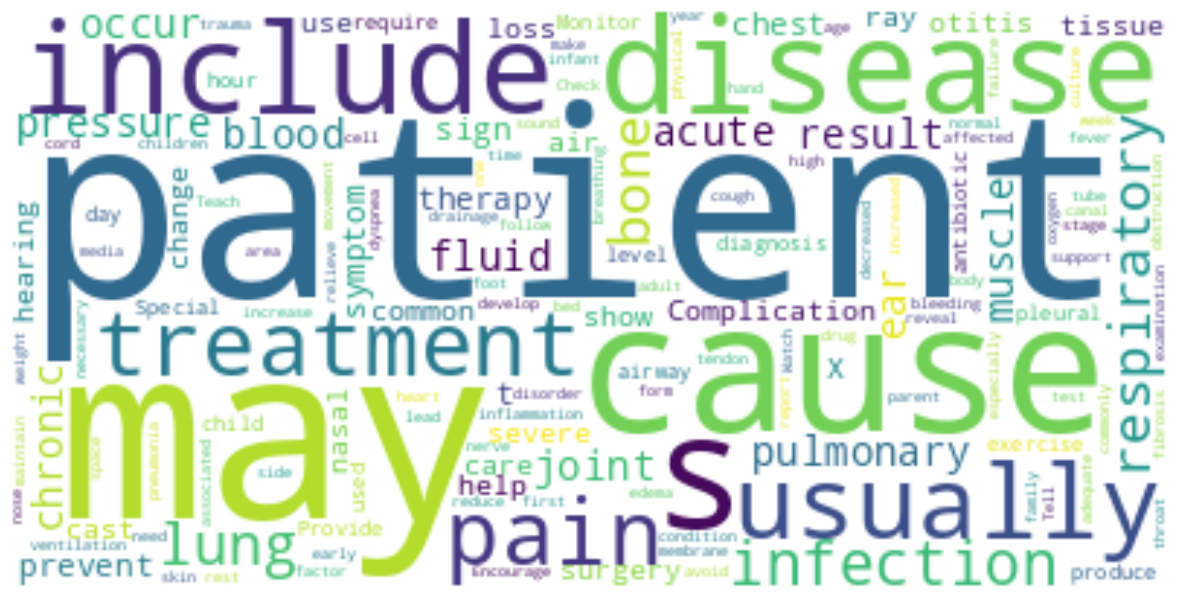

In [15]:
All_text = list(df.string_values)
All_text = " ".join(All_text)
word_cloud2 = WordCloud(collocations = False, background_color = 'white').generate(All_text)
plt.figure(figsize=(15,10))
plt.imshow(word_cloud2, interpolation='bilinear')
plt.axis("off")
plt.show()

### plot the most common words in the data before perform any data pre-processing

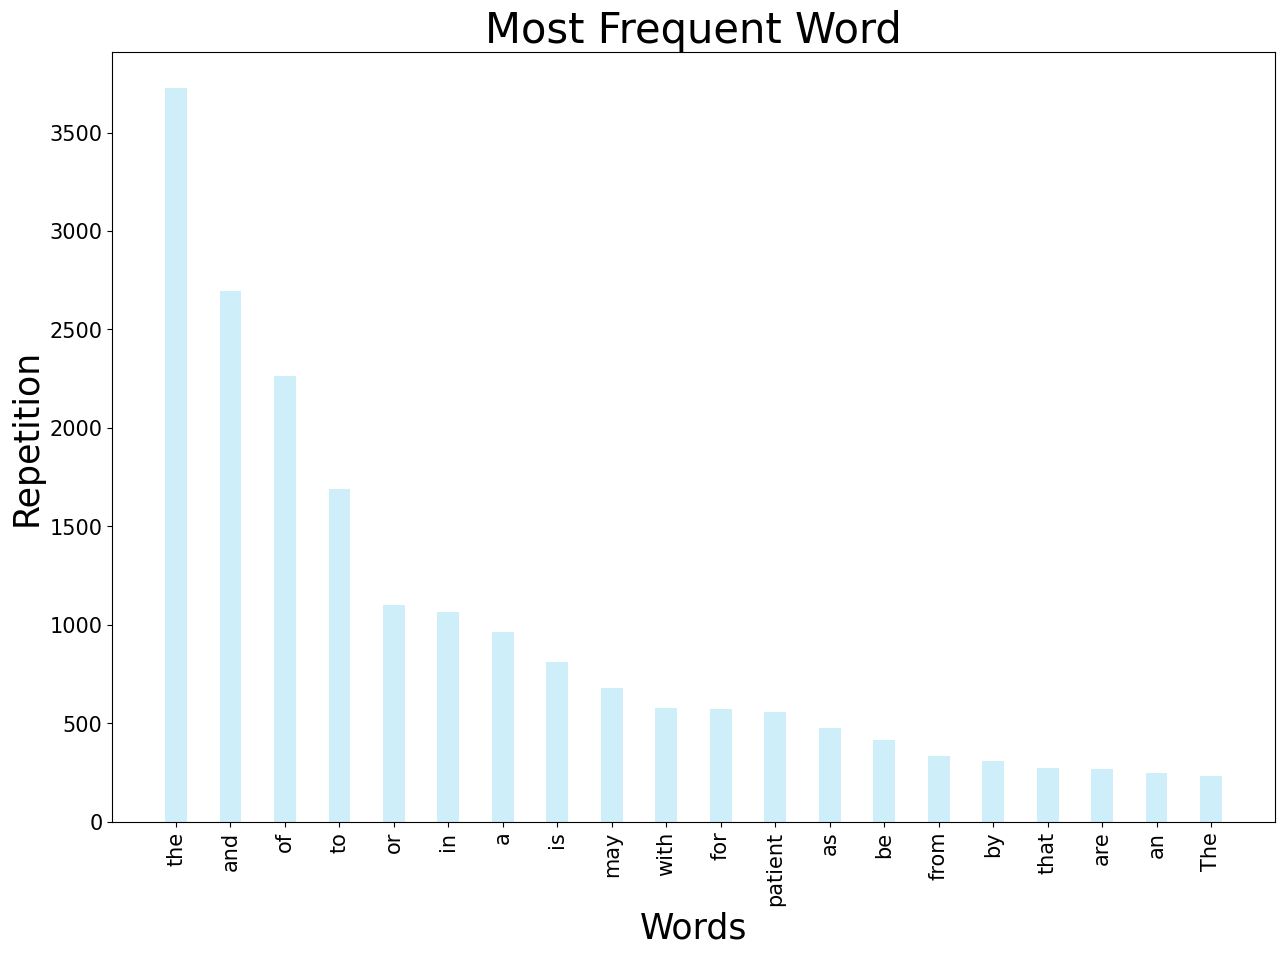

In [16]:
freq_words = get_freq_word(df.string_values)
freq_words.columns = ['WORD', 'COUNT']

plt.figure(figsize=(15,10))
plt.bar(freq_words.WORD[:20], freq_words.COUNT[:20], color ='#ceeffa',
        width = 0.4)
plt.xticks(rotation=90 ,fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel("Words" , fontsize = 25)
plt.ylabel("Repetition", fontsize = 25)
plt.title("Most Frequent Word", fontsize = 30)
plt.show();

In [17]:
# Import necessary modules
import ssl
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
ssl._create_default_https_context = ssl._create_unverified_context

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Import WordNetLemmatizer, and stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# import spcay framework
import spacy
nlp = spacy.load("en_core_web_sm")
from spacy.symbols import amod

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [18]:
# Import Counter
import nltk
nltk.download('punkt_tab')
from collections import Counter

# Tokenize the article: tokens
tokens = word_tokenize(All_text)

# Convert the tokens into lowercase: lower_tokens
lower_tokens = [t.lower() for t in tokens]

# Create a Counter with the lowercase tokens: bow_simple
bow_simple = Counter(lower_tokens)

# Print the 10 most common tokens
print(bow_simple.most_common(10))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[(',', 5819), ('the', 3982), ('.', 3365), ('and', 2843), ('of', 2274), ('to', 1747), ('in', 1192), ('or', 1129), ('a', 1051), ('(', 830)]


In [19]:
# Retain alphabetic words: alpha_only
alpha_only = [t for t in lower_tokens if t.isalpha()]

# Remove all stop words: no_stops
no_stops = [t for t in alpha_only if t not in stopwords.words('english')]

# Instantiate the WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()

# Lemmatize all tokens into a new list: lemmatized
lemmatized = [wordnet_lemmatizer.lemmatize(t) for t in no_stops]

# Create the bag-of-words: bow
bow = Counter(lemmatized)

# Print the 200 most common tokens
print(bow.most_common(200))

[('patient', 807), ('may', 691), ('cause', 252), ('usually', 213), ('disease', 212), ('also', 208), ('pain', 207), ('treatment', 191), ('infection', 191), ('lung', 186), ('bone', 182), ('respiratory', 181), ('include', 171), ('pulmonary', 170), ('result', 162), ('joint', 158), ('fluid', 148), ('acute', 146), ('child', 146), ('blood', 139), ('ear', 137), ('pressure', 134), ('chronic', 134), ('therapy', 134), ('chest', 131), ('muscle', 129), ('prevent', 126), ('symptom', 117), ('nasal', 114), ('severe', 113), ('sign', 111), ('cast', 108), ('use', 107), ('loss', 106), ('change', 106), ('surgery', 104), ('show', 100), ('otitis', 98), ('tissue', 95), ('hearing', 94), ('help', 94), ('care', 92), ('common', 90), ('produce', 87), ('occurs', 87), ('air', 86), ('level', 84), ('used', 83), ('diagnosis', 81), ('pleural', 80), ('antibiotic', 79), ('exercise', 79), ('airway', 78), ('drainage', 78), ('test', 77), ('hour', 76), ('provide', 76), ('form', 75), ('monitor', 73), ('inflammation', 72), ('fa

In [20]:
df['spacy_doc'] = list(nlp.pipe(df.string_values))

In [21]:
doc_adj = [token.text.lower() for doc in df.spacy_doc for token in doc if token.pos_=='ADJ']
doc_noun = [token.text.lower() for doc in df.spacy_doc for token in doc if token.pos_=='NOUN']

In [22]:
Counter(doc_adj).most_common(10)

[('such', 199),
 ('respiratory', 176),
 ('other', 154),
 ('pulmonary', 144),
 ('chronic', 137),
 ('severe', 116),
 ('acute', 115),
 ('common', 94),
 ('joint', 80),
 ('normal', 76)]

In [23]:
Counter(doc_noun).most_common(10)

[('patient', 613),
 ('disease', 208),
 ('pain', 207),
 ('treatment', 206),
 ('infection', 157),
 ('bone', 148),
 ('blood', 147),
 ('patients', 143),
 ('therapy', 138),
 ('lung', 128)]

In [24]:
# save the adjective words in list
adj_list = list(set(doc_adj))

In [25]:
print(len(adj_list))

2403


In [26]:
# defined stop words in topic domain

stop_words = ["patient", "may", "disease", "cause", "treatment", "also", "symptom", "usually", "sign",
                "diagnosis", "result", "pain", "include", "pressure", "lung", "pulmonary", "respiratory",
                "chest", "fluid", "complication", "change", "blood", "infection", "therapy", "prevent",
                "acute", "care", "child", "level", "air", "use", "severe", "help", "used", "exercise",
                "normal", "incidence", "pneumonia","tissue", "show", "chronic", "failure", "cast", "increased",
                "monitor", "hypoxemia", "produce", "edema", "increase", "space", "occurs", "cough", "alveolar",
                "heart", "pathophysiology", "sputum", "provide", "decreased", "pneumothorax", "test", "special",
                "tube", "condition", "common", "surgery","secretion", "fibrosis", "disorder", "pa", "area", "form",
                "cell", "skin", "drainage", "tb", "year", "commonly", "check", "teach", "rest", "watch", "encourage",
                "underlying", "consideration", "et", "early", "hour", "family", "need", "effusion", "body", "drug", "support",
                "rate", "syndrome", "requires", "inflammation", "abg", "side", "infant", "however", "upper", "cor", "pulmonale",
                 "ventilator", "mechanical", "breath", "maintain" , "foot", "day", "bed", "parent", "especially", "fever", "culture",
                'system', 'within', 'factor', 'amount', 'death', 'movement', 'progress', 'volume', 'one', 'stage', 'report',
                'avoid', 'respiration', 'trauma', 'occur', 'atelectasis', 'hand', 'includes', 'weight', 'tendon', 'hypertension',
                'le', 'time', 'lead', 'damage', 'causing', 'require', 'activity', 'injury', 'risk', 'mm', 'measure', 'examination',
                'nerve', 'stress', 'make', 'al', 'see', 'decrease', 'age', 'hg''case', 'month', 'coughing', 'develops', 'formation',
                'without', 'site', 'every', 'reduce', 'relieve', 'effect','percussion', 'ordered', 'develop', 'affect', 'loss', 'flow',
                'lesion', 'technique', 'exposure', 'gas', 'finding', 'procedure', 'begin', 'wall', 'immediately', 'type', 'response',
                'position', 'needed', 'administer', 'control', 'ass', 'increasing', 'although', 'tell', 'output', 'give', 'analysis',
                'history', 'often' ,'week', 'home', 'perform','function', 'typically', 'frequently', 'adult', 'indicate', 'administration',
                'explain', 'using', 'suggest', 'called', 'center', 'head', 'people', 'resulting', 'including', 'period', 'feature'
                   ]

In [27]:
# marge (adjective & topic domain stop words) list
new_stopwords = adj_list+stop_words

In [28]:
stpwrd = stopwords.words('english')

In [29]:
print(f' adjective words = {len(adj_list)}')
print(f' topic domain stop words = {len(stop_words)}')
print(f' marge adj_list & stop_words =  {len(new_stopwords)}')
print(f' english stop words = {len(stpwrd)}')

 adjective words = 2403
 topic domain stop words = 216
 marge adj_list & stop_words =  2619
 english stop words = 198


In [30]:
stpwrd.extend(new_stopwords)

print(f'after marge all of the stop words = {len(stpwrd)}')

after marge all of the stop words = 2817


In [31]:
# Remove all stop words: no_stops
no_stops01 = [t for t in lemmatized if t not in stpwrd ]

# Create the bag-of-words: bow
bow = Counter(no_stops01)

# Print the 100 most common tokens
print(bow.most_common(100))

[('bone', 182), ('ear', 137), ('muscle', 129), ('otitis', 98), ('hearing', 94), ('airway', 78), ('oxygen', 69), ('medium', 68), ('bleeding', 62), ('membrane', 59), ('ventilation', 56), ('obstruction', 55), ('breathing', 54), ('cord', 54), ('dyspnea', 52), ('abscess', 49), ('deformity', 47), ('throat', 45), ('canal', 45), ('hip', 45), ('nose', 43), ('case', 43), ('fracture', 43), ('copd', 43), ('thepatient', 42), ('place', 42), ('sinusitis', 42), ('instruct', 41), ('must', 40), ('advise', 40), ('attack', 39), ('brace', 39), ('sinus', 38), ('keep', 38), ('discharge', 37), ('tumor', 35), ('swelling', 35), ('traction', 35), ('neck', 34), ('reveals', 34), ('aspiration', 34), ('disk', 33), ('motion', 32), ('ofthe', 32), ('caused', 32), ('medication', 32), ('generally', 32), ('intake', 32), ('arthritis', 32), ('septum', 31), ('externa', 31), ('tip', 31), ('leg', 31), ('mouth', 30), ('organism', 30), ('promote', 30), ('dystrophy', 29), ('kyphosis', 29), ('around', 28), ('polyp', 28), ('removal

### plot word cloud after did the pre-process

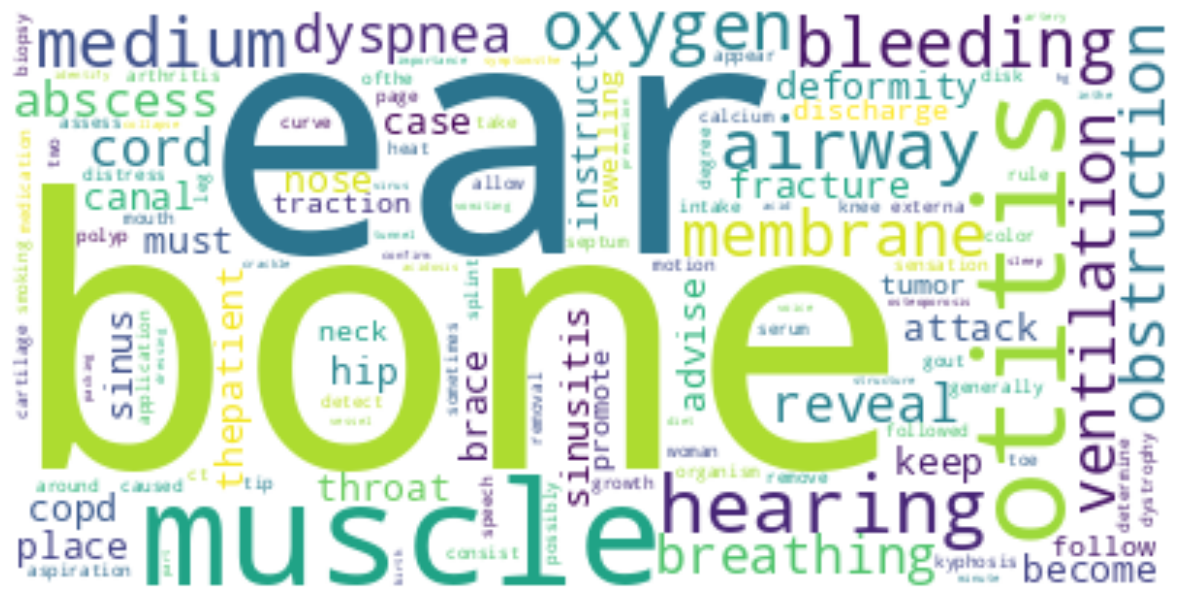

In [32]:
All_text = " ".join(no_stops01)
word_cloud2 = WordCloud(collocations = False, background_color = 'white').generate(All_text)
plt.figure(figsize=(15,10))
plt.imshow(word_cloud2, interpolation='bilinear')
plt.axis("off")
plt.show()

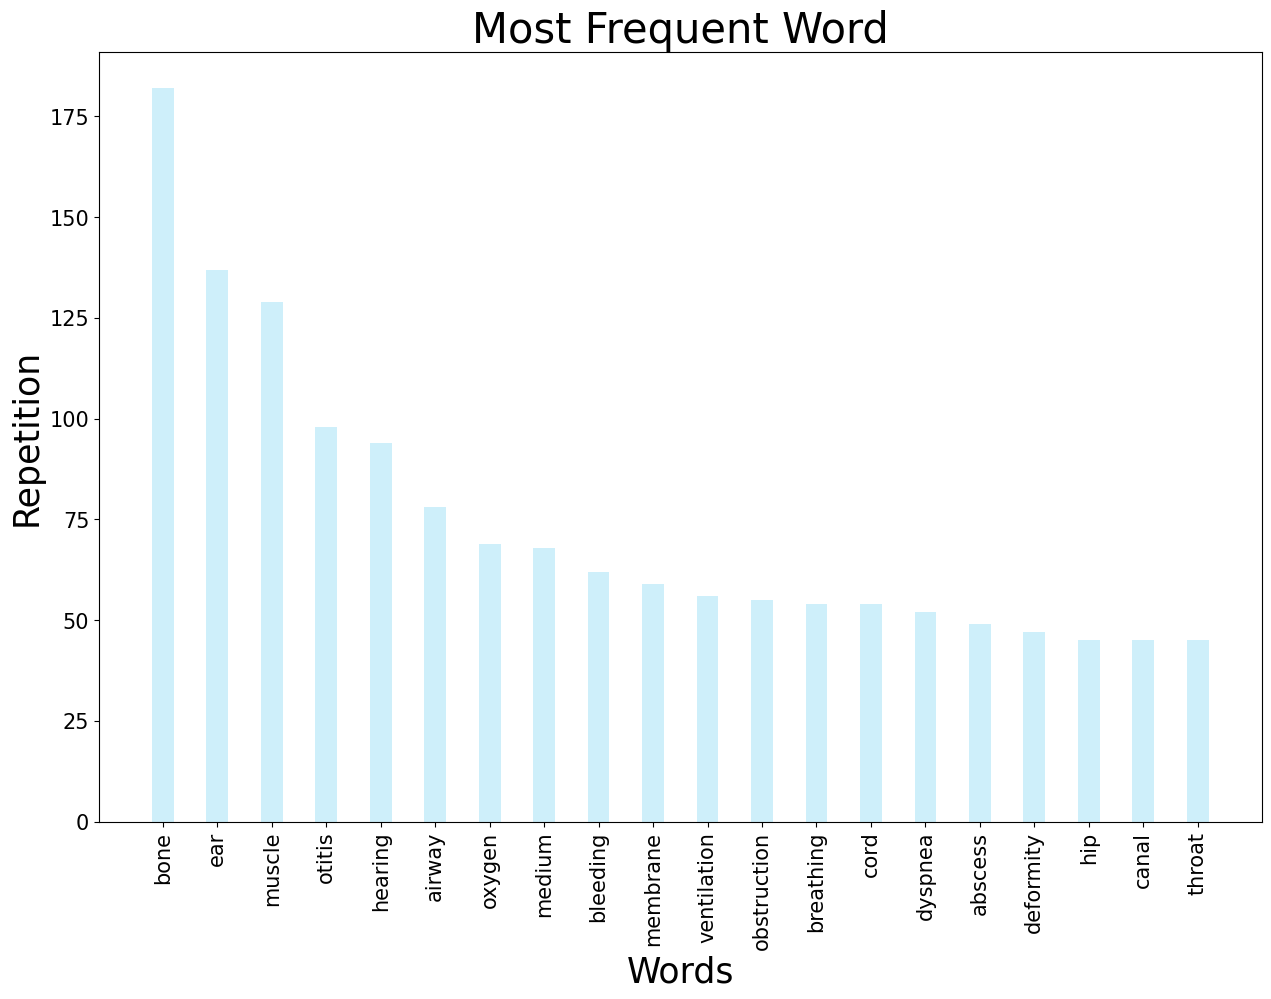

In [33]:
freq_words = get_freq_word(no_stops01)
freq_words.columns = ['WORD', 'COUNT']

plt.figure(figsize=(15,10))
plt.bar(freq_words.WORD[:20], freq_words.COUNT[:20], color ='#ceeffa',
        width = 0.4)
plt.xticks(rotation=90 ,fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel("Words" , fontsize = 25)
plt.ylabel("Repetition", fontsize = 25)
plt.title("Most Frequent Word", fontsize = 30)
plt.show();

### Save dataframe into csv file formate

In [34]:
corpus = " ".join(no_stops01)
string = corpus
df01 = pd.DataFrame([string], columns=['string_values'])

In [35]:
df01.to_csv('all_chapters.csv', 'index=False)

In [36]:
# save stop words list in pickle file, to use it later
import pickle
with open('stop_words.ob', 'wb') as fp:
    pickle.dump(stpwrd, fp)